In [1]:
from datetime import date
import pandas as pd
import os
import glob
import pycytominer
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2 

In [2]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [3]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

compound_path = parent_directory + 'compound_analysis/'

input_path = parent_directory + "results/"
output_path =  parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"

In [4]:
nocodazole_cluster = pd.read_csv(compound_path + 'nocodazole cluster.csv')
nocodazole_cluster.shape

(18, 20)

In [5]:
nocodazole_cluster.head()

,Metadata_inchi,Metadata_inchikey,Metadata_mw,Metadata_synonyms,Metadata_Plate,Metadata_name,Metadata_EOS,Metadata_pdid,Sensescence_params,Metadata_smiles,Metadata_Object_Count,Metadata_PAINS_Family_C,Metadata_Partner,Metadata_DMSO,Metadata_Tetrandrine,Metadata_Nocodazole,Metadata_tubulin,UMAP_Axis_1,UMAP_Axis_2,Selected (Scatter Plot)
0,InChI=1S/C46H56N4O10/c1-7-42(55)22-28-23-45(40...,OGWKCGZFUXNPDA-CFWMRBGOSA-N,824.40,Leurocristine;NSC-67574;22-Oxovincaleukoblasti...,B1001,vincristine,EOS100001,PD003310,True,CC[C@]1(O)C[C@@H]2CN(CCc3c([nH]c4ccccc34)[C@@]...,421.0,NaN,Bioactives,False,False,False,True,0.738269,10.027822,1
1,InChI=1S/C18H22O5/c1-20-15-8-7-12(9-14(15)19)5...,UXDFUVFNIAJEGM-UHFFFAOYSA-N,318.15,Erianin,B1001,Erianin,EOS100234,PD065187,False,COc1ccc(CCc2cc(OC)c(OC)c(OC)c2)cc1O,594.0,NaN,Bioactives,False,False,False,True,0.696348,10.002889,1
2,InChI=1S/C16H13NO2/c1-19-13-7-8-14-12(9-13)10-...,ICMIJSRDISNKOC-UHFFFAOYSA-N,251.09,D-64131;D64131,B1002,D-64131,EOS100406,PD012572,False,COc1ccc2[nH]c(C(=O)c3ccccc3)cc2c1,511.5,NaN,Bioactives,False,False,False,True,0.492463,9.810324,1
3,InChI=1S/C27H43N3O4/c1-17(2)20(16-18(3)25(33)3...,CNTMOLDWXSVYKD-PSRNMDMQSA-N,473.33,HTI 286;TALTOBULIN;HTI-286;SPA-110,B1002,TALTOBULIN,EOS100492,PD016647,True,CN[C@H](C(=O)N[C@H](C(=O)N(C)[C@H](/C=C(\C)C(=...,567.5,NaN,Bioactives,False,False,False,True,0.663292,9.976361,1
4,InChI=1S/C16H13N3O3/c1-22-16(21)19-15-17-12-8-...,OPXLLQIJSORQAM-UHFFFAOYSA-N,295.10,Vermox;Mebenvet;CHLORFENSON;MEBENDAZOLE;Telmin...,B1003,MEBENDAZOLE,EOS100806,PD001898,False,COC(=O)Nc1nc2cc(C(=O)c3ccccc3)ccc2[nH]1,491.0,NaN,Bioactives,False,False,False,True,0.543867,9.876522,1


In [6]:
# TODO: Load FMP HepG2 data
# TODO: compare profiles within this selection with Tubulin
# TODO: Compare profiles within this selection with Tetrandrine
# TODO: Compare profiles with randomly selected active compounds

In [7]:
# Maybe viz: Compounds structure, Median Cell Number, Induction, "Similarity" - Correlation to Tubulin


In [8]:
file_HepG2_Median_type = '/*[0-9]_' + 'FMP_HepG2_norm_reduced_filtered_median.csv'
files_HepG2_Median = glob.glob(input_path + file_HepG2_Median_type)

### gets latest file
max_file_HepG2_Median = max(files_HepG2_Median, key=os.path.getctime)

### load file
data_HepG2_Median = pd.read_csv(max_file_HepG2_Median)
data_HepG2_Median.shape

(801, 658)

In [9]:
features = UTIL.get_feature_vector(data_HepG2_Median)

In [10]:
nocodazole_median_feature_vector = data_HepG2_Median[data_HepG2_Median['Metadata_EOS'] == 'Nocodazole'][features].median().to_numpy()

In [11]:
tetrandrine_median_feature_vector = data_HepG2_Median[data_HepG2_Median['Metadata_EOS'] == 'Tetrandrine'][features].median().to_numpy()

In [12]:
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau

corr = []

for compound in nocodazole_cluster['Metadata_EOS']:

    if compound != 'Nocodazole':

        compound_feature_vector = data_HepG2_Median[data_HepG2_Median['Metadata_EOS'] == compound][features].iloc[0, :].to_numpy()

        corr_noco, p_value_noco = pearsonr(nocodazole_median_feature_vector, compound_feature_vector)
        print(f"{compound} vs Nocodazole: {corr_noco}, p-value: {p_value_noco}")

        corr_tet, p_value_tet = pearsonr(tetrandrine_median_feature_vector, compound_feature_vector)
        print(f"{compound} vs Tetrandrine: {corr_tet}, p-value: {p_value_tet}")


        corr.append({'Compound': compound,
                           'Corr_Nocodazole': corr_noco,
                           'P_Nocodazoleg':p_value_noco,
                           'Corr_Tetrandrine':corr_tet,
                           'P_Tetrandrine':p_value_tet})
        
corr_df = pd.DataFrame(corr)

EOS100001 vs Nocodazole: 0.9148316936503802, p-value: 6.00328209108875e-259
EOS100001 vs Tetrandrine: 0.1808882501404159, p-value: 3.231321866549674e-06
EOS100234 vs Nocodazole: 0.9513670499261748, p-value: 0.0
EOS100234 vs Tetrandrine: 0.14998135941208793, p-value: 0.00011811932039315086
EOS100406 vs Nocodazole: 0.8502863378384109, p-value: 6.606219793595514e-184
EOS100406 vs Tetrandrine: 0.30543588467540395, p-value: 1.3741380065872667e-15
EOS100492 vs Nocodazole: 0.9439393274363558, p-value: 4.9293952e-316
EOS100492 vs Tetrandrine: 0.23091920019899606, p-value: 2.3003925791072236e-09
EOS100806 vs Nocodazole: 0.8439739279018812, p-value: 1.5359926398713962e-178
EOS100806 vs Tetrandrine: 0.218655339066519, p-value: 1.608491267034385e-08
EOS100861 vs Nocodazole: 0.9575636896561535, p-value: 0.0
EOS100861 vs Tetrandrine: 0.16615510612280426, p-value: 1.948191371225629e-05
EOS100922 vs Nocodazole: 0.8929577297978182, p-value: 3.362175577331633e-228
EOS100922 vs Tetrandrine: 0.26364443712

In [13]:
def null_corr(df, n_samples, metadata_compound_name):
    """
        Null distribution between random "replicates".
        Parameters:
        ------------
        df: pandas.DataFrame
        n_samples: int
        n_replicates: int
        metadata_compound_name: Compound name feature
        Returns:
        --------
        list-like of correlation values, with a  length of `n_samples`
    """


    null_corr = []
    while len(null_corr) < n_samples:
        
        compounds = random.choices([_ for _ in range(len(df))], k = n_replicates)
        sample = df.loc[compounds].copy()
        if len(sample[metadata_compound_name].unique()) == n_replicates:
            sample_features = sample.loc[:, get_feature_vector(sample)]
            corr = np.corrcoef(sample_features)
            np.fill_diagonal(corr, np.nan)
            null_corr.append(np.nanmedian(corr))  # median non-replicate correlation
    return null_corr

In [14]:
data_HepG2_Median.reset_index(drop=True, inplace=True)
sampled_df = data_HepG2_Median.sample(n=10000, random_state=42, replace=True)

null_corr = []

for compound in sampled_df['Metadata_EOS']:

    if compound != 'Nocodazole':

        compound_feature_vector = sampled_df[sampled_df['Metadata_EOS'] == compound][features].iloc[0, :].to_numpy()

        corr_noco, p_value_noco = pearsonr(nocodazole_median_feature_vector, compound_feature_vector)

        null_corr.append({'Compound': compound,
                          'Corr_Nocodazole': corr_noco,
                          'P_Nocodazoleg':p_value_noco})
        
null_corr = pd.DataFrame(null_corr)
        

In [15]:
perc_95 = np.nanpercentile(null_corr['Corr_Nocodazole'], 95)
perc_95

0.785646260799509

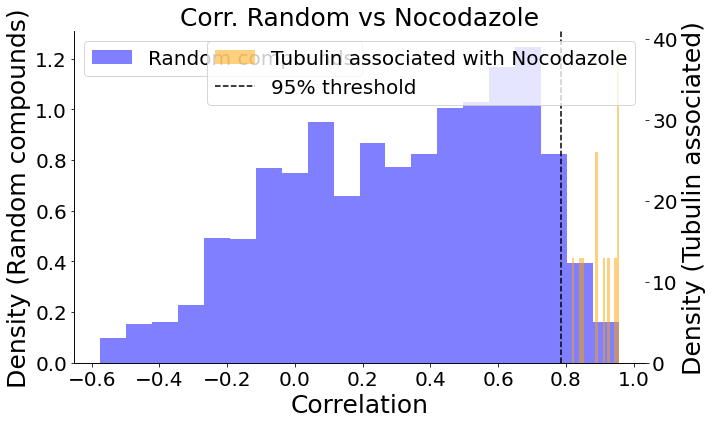

In [17]:
plt.figure(figsize=(10, 6))

# Create the first axis (left)
ax1 = plt.gca()

# Plot the first histogram (Random compounds)
ax1.hist(null_corr['Corr_Nocodazole'], label='Random compounds', density=True, bins=20, alpha=0.5, color='blue')
ax1.set_xlabel("Correlation", fontsize=25)
ax1.set_ylabel("Density (Random compounds)", fontsize=25)
ax1.tick_params(axis='both', labelsize=20)

# Create the second axis (right)
ax2 = ax1.twinx()

# Plot the second histogram (Tubulin associated with Nocodazole) on the second axis
ax2.hist(corr_df['Corr_Nocodazole'], label='Tubulin associated with Nocodazole', bins=20, alpha=0.5, color='orange', density=True)
ax2.set_ylabel("Density (Tubulin associated)", fontsize=25)
ax2.tick_params(axis='both', labelsize=20)

# Add vertical line for the 95% threshold
plt.axvline(perc_95, label='95% threshold', color='black', linestyle='--')

# Set the title and legend
plt.title("Corr. Random vs Nocodazole", fontsize=25)
ax1.legend(fontsize=20, loc='upper left')
ax2.legend(fontsize=20, loc='upper right')

# Adjust layout to prevent overlap
sns.despine()
plt.tight_layout()

plt.savefig(figure_path + os.sep + 'Noco_Corr.pdf', dpi=300, bbox_inches='tight')


# Show plot
plt.show()